# Maintenance prédictive par réseau de neurones : du jeu de données au modèle embarquable

Conception, entraînement et export d'un classifieur multiclasse de défaillances machines, destiné à être déployé sur microcontrôleur **STM32L4R9I-DISCO** (ARM Cortex-M4, 120 MHz).

**Auteurs :** Edouard LE · Laure RIVIER

Ce notebook couvre la partie *desktop* de la chaîne : analyse et nettoyage des données, traitement du déséquilibre de classes, entraînement, évaluation et conversion au format TensorFlow Lite. Le déploiement sur cible, le protocole UART et la validation on-target sont documentés dans le [README du projet](../README.md).

## 1. Le jeu de données

Le **AI4I 2020 Predictive Maintenance Dataset** contient 10 000 relevés de capteurs industriels. Chaque observation décrit l'état de fonctionnement d'une machine et porte un label indiquant si une défaillance s'est produite et, le cas échéant, de quel type.

Les cinq types de défaillance présents dans le jeu de données brut :

| Code | Défaillance |
|---|---|
| `TWF` | Tool Wear Failure — usure de l'outil |
| `HDF` | Heat Dissipation Failure — dissipation thermique |
| `PWF` | Power Failure — alimentation |
| `OSF` | Overstrain Failure — surcharge |
| `RNF` | Random Failure — défaillance aléatoire |

Source : UCI Machine Learning Repository (fichier `ai4i2020.csv`).

## Objectif et démarche

Construire un modèle de classification capable de prédire, à partir de cinq mesures capteurs, si une machine est en défaillance et de quel type — avec une empreinte mémoire compatible d'un microcontrôleur.

La démarche suit quatre étapes :

1. **Analyse exploratoire** — comprendre la structure des données et identifier les incohérences d'étiquetage
2. **Modèle de référence** — entraîner sans traiter le déséquilibre, pour mesurer l'ampleur du problème
3. **Modèle final** — rééquilibrer le jeu d'entraînement et comparer
4. **Export embarqué** — conversion TensorFlow Lite pour la cible STM32

Le fil conducteur est le compromis central de l'IA embarquée : maximiser la capacité de détection tout en gardant un modèle assez frugal pour tenir dans quelques kilooctets.

## 2. Analyse exploratoire

### Environnement

Ensemble des dépendances utilisées dans le notebook.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import LabelEncoder
from imblearn.under_sampling import RandomUnderSampler
from tensorflow.keras.utils import to_categorical

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, confusion_matrix


### Chargement des données

Lecture du CSV et aperçu des premières lignes.

In [3]:
df = pd.read_csv('ai4i2020.csv')

display(df.head())

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


### Distribution globale des défaillances

Répartition des machines entre fonctionnement normal et défaillance.

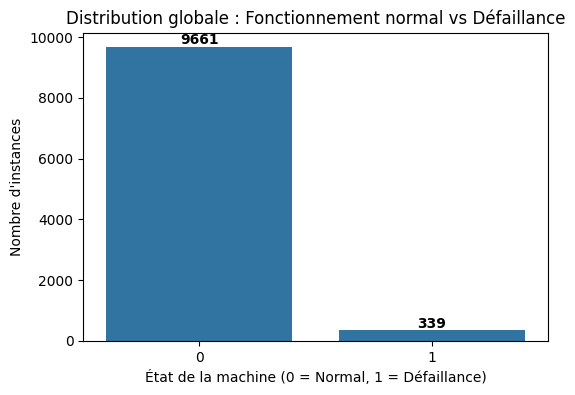

In [4]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df, x='Machine failure')

plt.title('Distribution globale : Fonctionnement normal vs Défaillance', fontsize=12)
plt.xlabel('État de la machine (0 = Normal, 1 = Défaillance)')
plt.ylabel("Nombre d'instances")

# Ajout des valeurs exactes au-dessus des barres
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontweight='bold')

plt.show()

#### Ce que montre la distribution

Le jeu de données est fortement déséquilibré : on ne compte que **339 défaillances pour 10 000 observations**, soit environ 3 % des cas. Les machines en fonctionnement normal représentent donc la quasi-totalité des exemples.

#### Conséquence attendue sur l'apprentissage

Avec une telle répartition, le modèle apprendra qu'un fonctionnement normal est de très loin l'issue la plus probable. Il aura donc intérêt, pour minimiser sa fonction de coût, à prédire systématiquement « pas de défaillance » — sans jamais apprendre à reconnaître les pannes. C'est cette hypothèse que la section 3 vérifie expérimentalement.

### Répartition par type de défaillance

Décompte des occurrences de chaque type de panne (`TWF`, `HDF`, `PWF`, `OSF`, `RNF`) sur l'ensemble du jeu de données, valeurs exactes affichées au-dessus des barres.

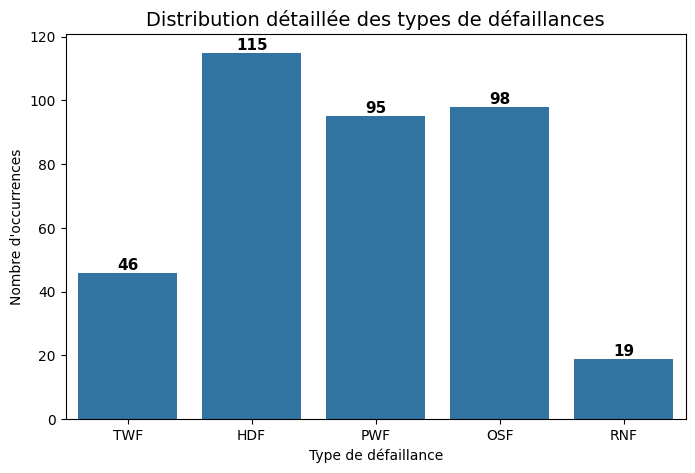

In [5]:
failure_types = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']

failure_counts = df[failure_types].sum()   # somme de chaque colonne pour obtenir le nombre total de chaque type de panne

plt.figure(figsize=(8, 5))
ax = sns.barplot(x=failure_counts.index, y=failure_counts.values)

plt.title('Distribution détaillée des types de défaillances', fontsize=14)
plt.xlabel('Type de défaillance')
plt.ylabel('Nombre d\'occurrences')

# Ajout des étiquettes de valeurs exactes au-dessus de chaque barre
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', 
                fontsize=11, fontweight='bold', color='black')

plt.show()

#### Observations

Les défaillances ont des origines réparties de manière très inégale. Les pannes liées à la dissipation thermique (**HDF**, 115 cas), aux surcharges (**OSF**, 98 cas) et à l'alimentation (**PWF**, 95 cas) dominent largement : elles représentent 308 pannes sur 339, soit 91 % du total. À l'inverse, l'usure de l'outil (**TWF**, 46 cas) est deux fois moins fréquente, et les pannes aléatoires (**RNF**, 19 cas) sont marginales.

Un second constat, plus important, ressort de ce comptage : la somme des types de panne (373) **dépasse le nombre de machines effectivement en panne** (339). Certaines lignes portent donc plusieurs flags à 1, ce qui signifie que les types de défaillance ne sont pas mutuellement exclusifs dans le jeu de données brut. Un nettoyage sera nécessaire avant tout entraînement.

### Types de défaillance parmi les machines réellement en panne

Le même décompte, restreint cette fois aux lignes où `Machine failure == 1`. Une catégorie supplémentaire, *No Specific Failure*, compte les machines déclarées en panne sans qu'aucun type ne soit renseigné — croiser les deux vues permet d'isoler les incohérences d'étiquetage.

      TWF  HDF  PWF  OSF  RNF
50      0    0    1    0    0
69      0    0    1    1    0
77      1    0    0    0    0
160     0    0    0    1    0
161     0    0    0    1    0
...   ...  ...  ...  ...  ...
9758    1    0    0    0    0
9764    0    0    1    0    0
9822    0    0    0    1    0
9830    0    0    0    1    0
9974    0    0    1    1    0

[339 rows x 5 columns]
TWF     46
HDF    115
PWF     95
OSF     98
RNF      1
dtype: int64


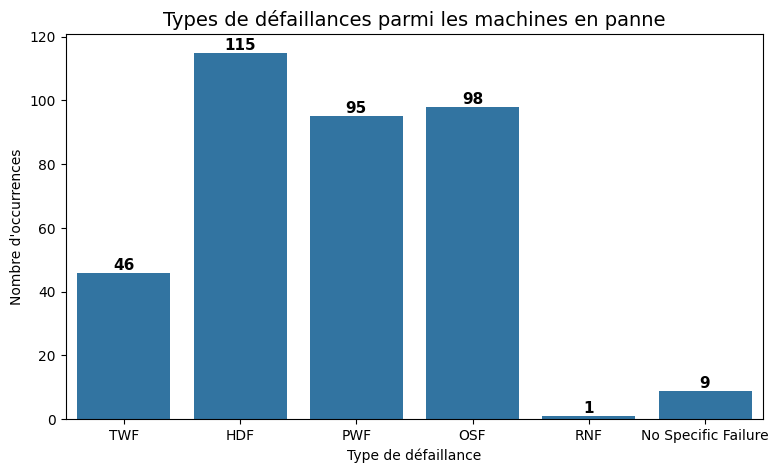

In [6]:
# Filtrer uniquement les machines en panne
df_failed = df[df['Machine failure'] == 1]
failure_types = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']
failure_counts = df_failed[failure_types].sum()
print(df_failed[failure_types])
print(failure_counts)

# Compter les cas sans type de panne identifié
no_specific = (df_failed[failure_types].sum(axis=1) == 0).sum()
failure_counts['No Specific Failure'] = no_specific

plt.figure(figsize=(9, 5))
ax = sns.barplot(x=failure_counts.index, y=failure_counts.values)

plt.title('Types de défaillances parmi les machines en panne', fontsize=14)
plt.xlabel('Type de défaillance')
plt.ylabel("Nombre d'occurrences")

# ajout des quantités au dessus de l'histogramme
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', 
                fontsize=11, fontweight='bold', color='black')

plt.show()

#### Incohérence identifiée

La comparaison des deux distributions révèle une incohérence nette : sur l'ensemble des données, on comptait 19 occurrences de `RNF`, alors qu'en se restreignant aux machines en panne il n'en reste plus qu'une seule. Autrement dit, la quasi-totalité des lignes portant `RNF = 1` ont un label global `Machine failure = 0`.

C'est une erreur d'étiquetage du jeu de données d'origine, qu'il faudra traiter explicitement — un modèle entraîné sur ces lignes apprendrait des associations contradictoires.

### Typage des colonnes

Vérification des types de données avant sélection des variables.

In [7]:
print(df.dtypes)


UDI                          int64
Product ID                     str
Type                           str
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Machine failure              int64
TWF                          int64
HDF                          int64
PWF                          int64
OSF                          int64
RNF                          int64
dtype: object


### Choix des variables d'entrée et de sortie

Il s'agit de prédire l'occurrence d'une défaillance **et** son type à partir des relevés de fonctionnement : c'est donc un problème de **classification multiclasse**.

**Entrées (X)** — les cinq grandeurs physiques mesurées sur la machine :

| Variable | Type |
|---|---|
| `Air temperature [K]` | float64 |
| `Process temperature [K]` | float64 |
| `Rotational speed [rpm]` | int64 |
| `Torque [Nm]` | float64 |
| `Tool wear [min]` | int64 |

**Sorties (Y)** — le type de défaillance : `TWF`, `HDF`, `PWF`, `OSF`, `RNF`, auxquels s'ajoutera une classe `No Error` pour les machines saines (voir section 3).

Les colonnes d'identification (`UDI`, `Product ID`) et le label agrégé `Machine failure` sont écartés des entrées : les premières ne portent aucune information physique, le second serait une fuite directe de la cible.

## 3. Modèle de référence — sans rééquilibrage

---

Cette première version sert de point de comparaison. L'objectif n'est pas d'obtenir un bon modèle, mais de **quantifier l'effet du déséquilibre** et de vérifier l'hypothèse formulée en section 2.

Le jeu de données est ici utilisé tel quel, sans aucune correction du déséquilibre de classes.

### Nettoyage et construction des cibles

Trois filtres sont appliqués pour rendre le problème cohérent en multiclasse :

1. **Type de panne sans `Machine failure`** — lignes avec un flag de type à 1 alors que le label global est à 0 (l'incohérence identifiée plus haut). Supprimées comme erreurs d'étiquetage.
2. **`Machine failure` sans type identifié** — machines déclarées en panne sans type renseigné. Supprimées car inexploitables en multiclasse.
3. **Défaillances multiples simultanées** — lignes cumulant plusieurs types à 1. Supprimées pour garantir qu'un exemple appartienne à exactement une classe.

Les cibles sont ensuite reformulées : le `Y` d'origine est une matrice **multi-label** (5 colonnes binaires indépendantes). `idxmax` identifie la panne active, une classe `No Error` est ajoutée explicitement pour les machines saines — indispensable en multiclasse, où le modèle doit toujours désigner une classe — et `get_dummies` produit l'encodage one-hot final sur `['HDF', 'No Error', 'OSF', 'PWF', 'TWF']`.

À noter : après nettoyage, **`RNF` disparaît entièrement** du jeu de données, toutes ses occurrences correspondant à des cas incohérents.

In [8]:
input_features = ['Air temperature [K]', 'Process temperature [K]',
            'Rotational speed [rpm]', 'Torque [Nm]',
            'Tool wear [min]']

output_features = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']

# Filtrage de df
# On eleve les pannes sans machine failure
idx_RNF = df.loc[(df[output_features].sum(axis=1) >= 1) & (df["Machine failure"] == 0)].index
df.drop(index=idx_RNF, inplace=True)
# On eleve les machine failure qui n'ont pas de type
idx_unknown_failure = df.loc[(df["Machine failure"] == 1) & (df[failure_types].sum(axis=1) == 0)].index
df.drop(index=idx_unknown_failure, inplace=True)
# On eleve les multipanes 
idx_unknown_failure = df.loc[(df[failure_types].sum(axis=1)>1)].index
df.drop(index=idx_unknown_failure, inplace=True)

# Ajout du label dans le cas de fonctionnement normal. En effet nous souhaitons faire du multiclass donc cette étape est essentielle
Y=df[output_features]
Y = np.where((Y == 0).all(axis=1), 'No Error', Y.idxmax(axis=1))
classes = ['HDF', 'No Error', 'OSF', 'PWF', 'TWF']
Y = pd.get_dummies(Y)[classes].values.astype(np.float32)
# On notera qu'il n'y a plus d'exemple RNF, il a disparu avec les filtres

X=df[input_features].values

print(Y)
print(np.shape(Y))
print(X)
print(np.shape(X))


[[0. 1. 0. 0. 0.]
 [0. 1. 0. 0. 0.]
 [0. 1. 0. 0. 0.]
 ...
 [0. 1. 0. 0. 0.]
 [0. 1. 0. 0. 0.]
 [0. 1. 0. 0. 0.]]
(9949, 5)
[[ 298.1  308.6 1551.    42.8    0. ]
 [ 298.2  308.7 1408.    46.3    3. ]
 [ 298.1  308.5 1498.    49.4    5. ]
 ...
 [ 299.   308.6 1645.    33.4   22. ]
 [ 299.   308.7 1408.    48.5   25. ]
 [ 299.   308.7 1500.    40.2   30. ]]
(9949, 5)


In [9]:
# paramètres de notre datasplit
TRAIN_RATIO = 0.8
VAL_RATIO = 0.1
TEST_RATIO = 0.1
DATASET_SIZE = len(X)

In [10]:
# On mélange une première fois les données
rng = np.random.default_rng(seed=42)
indices = rng.permutation(DATASET_SIZE)
X, Y = X[indices], Y[indices]

# On split les données en 3 datasets : test, validation, train
X_train, Y_train =X[:int(DATASET_SIZE*TRAIN_RATIO)], Y[:int(DATASET_SIZE*TRAIN_RATIO)]
X_test, Y_test=X[int(DATASET_SIZE*TRAIN_RATIO):int(DATASET_SIZE*(TRAIN_RATIO+TEST_RATIO))], Y[int(DATASET_SIZE*TRAIN_RATIO):int(DATASET_SIZE*(TRAIN_RATIO+TEST_RATIO))]
X_val, Y_val =X[int(DATASET_SIZE*(TRAIN_RATIO+TEST_RATIO)):int(DATASET_SIZE)], Y[int(DATASET_SIZE*(TRAIN_RATIO+TEST_RATIO)):int(DATASET_SIZE)]

X_val_raw  = X_val.copy()
X_test_raw = X_test.copy()

print(np.shape(X_train))
print(np.shape(X_test))
print(np.shape(X_val))

print(np.shape(Y_train))
print(np.shape(Y_test))
print(np.shape(Y_val))

print(Y)

(7959, 5)
(995, 5)
(995, 5)
(7959, 5)
(995, 5)
(995, 5)
[[0. 1. 0. 0. 0.]
 [0. 1. 0. 0. 0.]
 [0. 1. 0. 0. 0.]
 ...
 [0. 1. 0. 0. 0.]
 [0. 1. 0. 0. 0.]
 [0. 1. 0. 0. 0.]]


In [11]:
# Normalisation du jeu de données : moyenne 0 écart type 1
scaler = StandardScaler()

X_train=scaler.fit_transform(X_train)
X_val=scaler.transform(X_val)
X_test=scaler.transform(X_test)

# On sauvegarde les datasets pour réaliser l'inférence dessus
np.save('X_test_failure_prediction.npy', X_test.astype(np.float32))
np.save('Y_test_failure_prediction.npy', Y_test.astype(np.float32))

print(X_train)
print(np.shape(X_train))
print(np.mean(X_train))
print(np.std(X_train))

[[-1.30170051 -0.68163914 -0.39442813  0.14470698  0.758028  ]
 [-0.95332183 -0.74877647 -0.83580255  1.36302448 -0.38872477]
 [ 1.08718184  1.19820599  2.43588533 -1.828766   -1.12704505]
 ...
 [ 0.14158257  0.99679401 -0.52132328  0.73876262 -1.06420928]
 [ 0.3406561   0.66110738 -1.12269592  1.34288701 -0.6243589 ]
 [ 0.73880316  0.05687145 -0.39442813  0.08429454 -1.18988082]]
(7959, 5)
1.0039766201181512e-13
1.0000000000000002


### Architecture du modèle

Perceptron multicouche à trois couches cachées, avec `Dropout(0.5)` après chacune pour limiter le sur-apprentissage. Sortie `softmax` sur 5 classes, cohérente avec un problème multiclasse à classe unique active.

In [12]:
# On ajoute des couches de dropout pour empecher l'overfiting potentiel
model = keras.Sequential ([
    keras.layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(16, activation='relu'),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(Y_train.shape[1], activation='softmax')
])

c:\Users\rivie\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### Entraînement

Optimiseur Adam, perte `categorical_crossentropy`, 20 epochs, batch de 32. Les courbes d'accuracy et de perte sur les ensembles d'entraînement et de validation sont tracées pour détecter un éventuel sur-apprentissage.

Epoch 1/20
249/249 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.8520 - loss: 0.6181 - val_accuracy: 0.9769 - val_loss: 0.1501
Epoch 2/20
249/249 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9648 - loss: 0.2959 - val_accuracy: 0.9769 - val_loss: 0.1271
Epoch 3/20
249/249 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9680 - loss: 0.2245 - val_accuracy: 0.9769 - val_loss: 0.1113
Epoch 4/20
249/249 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9682 - loss: 0.2053 - val_accuracy: 0.9769 - val_loss: 0.1022
Epoch 5/20
249/249 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9681 - loss: 0.1870 - val_accuracy: 0.9769 - val_loss: 0.0988
Epoch 6/20
249/249 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9682 - loss: 0.1742 - val_accuracy: 0.9769 - val_loss: 0.0953
Epoch 7/20
249/249 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9682 - loss: 0.1700 - val_accuracy: 0.9769 - val_loss: 0.0967
Epoch 8/20
249/249 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9682 - loss: 0.1587 - val_accuracy: 0.

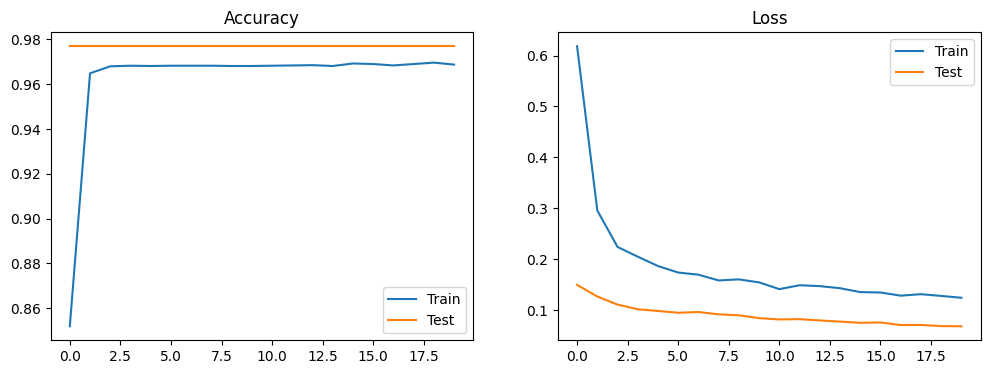

In [13]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Entraînement
history = model.fit(X_train, Y_train, epochs=20, batch_size=32, 
                    validation_data=(X_val, Y_val), verbose=1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history.history['accuracy'], label='Train')
ax1.plot(history.history['val_accuracy'], label='Test')
ax1.set_title('Accuracy')
ax1.legend()
ax2.plot(history.history['loss'], label='Train')
ax2.plot(history.history['val_loss'], label='Test')
ax2.set_title('Loss')
ax2.legend()
plt.show()



### Évaluation

L'accuracy globale est ici une métrique trompeuse : avec 97 % d'exemples sains, un modèle qui prédirait systématiquement `No Error` l'afficherait sans avoir rien appris. L'évaluation s'appuie donc sur la **matrice de confusion** et le **rappel par classe**, seuls capables de révéler ce comportement.

{0: 'TWF', 1: 'HDF', 2: 'PWF', 3: 'OSF', 4: 'RNF'} 

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
              precision    recall  f1-score   support

         HDF       0.00      0.00      0.00        14
    No error       0.97      1.00      0.98       965
         OSF       0.00      0.00      0.00         6
         PWF       0.00      0.00      0.00         7
         TWF       0.00      0.00      0.00         3

    accuracy                           0.97       995
   macro avg       0.19      0.20      0.20       995
weighted avg       0.94      0.97      0.96       995



c:\Users\rivie\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\rivie\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\rivie\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

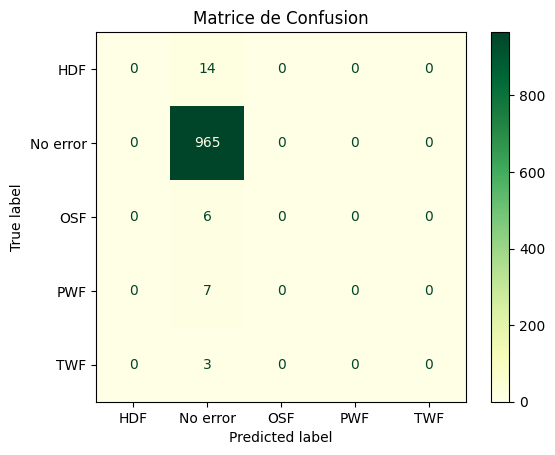

In [14]:
Y_df = pd.DataFrame(Y_test, columns=output_features)
class_mapping = {i: label for i, label in enumerate(Y_df.columns)}
print(class_mapping, "\n")

output_features = ['HDF', 'No error', 'OSF', 'PWF', 'TWF' ]

Y_pred = model.predict(X_test)

Y_pred_idx =np.argmax(Y_pred, axis=1)
Y_test_idx =np.argmax(Y_test, axis=1)

print(classification_report(Y_test_idx, Y_pred_idx, target_names=output_features))


cm = confusion_matrix(Y_test_idx, Y_pred_idx, labels=np.arange(len(output_features)))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=output_features)
disp.plot(cmap=plt.cm.YlGn)
plt.title("Matrice de Confusion")
plt.show()

#### Résultat de la référence

La matrice de confusion confirme l'hypothèse : le modèle prédit un fonctionnement normal dans **100 % des cas**. L'accuracy globale atteint 97 %, ce qui correspond exactement à la proportion d'exemples sains dans le jeu de test.

Le modèle n'a appris aucun pattern de défaillance — il a seulement appris à prédire la classe majoritaire, celle qui minimise sa fonction de coût. Le rappel est nul sur les cinq classes de panne, ce qui rend ce modèle totalement inutilisable en maintenance prédictive, malgré une accuracy apparemment excellente.

## 4. Modèle final — rééquilibrage par SMOTE

---

### Options de rééquilibrage envisagées

Trois approches étaient possibles :

| Approche | Principe | Décision |
|---|---|---|
| **Sur-échantillonnage** (SMOTE) | Génère des exemples synthétiques pour les classes minoritaires | **Retenue** |
| **Sous-échantillonnage** (RandomUnderSampler, Tomek Links) | Réduit la taille de la classe majoritaire | Écartée |
| **Pondération des classes** | Pénalise davantage les erreurs sur classes minoritaires à l'entraînement | Écartée |

Le sous-échantillonnage est écarté en raison de la rareté des données réelles : réduire la classe majoritaire aggraverait le manque global d'information. La pondération des classes reste une alternative valable, mais SMOTE seul suffit ici à rééquilibrer le problème.

*Références : [SMOTE](https://imbalanced-learn.org/stable/references/generated/imblearn.over_sampling.SMOTE.html) · [RandomUnderSampler](https://imbalanced-learn.org/stable/references/generated/imblearn.under_sampling.RandomUnderSampler.html) · [pondération des classes](https://www.tensorflow.org/tutorials/structured_data/imbalanced_data)*

### Rééquilibrage du jeu d'entraînement

SMOTE est appliqué **uniquement sur l'ensemble d'entraînement**, après le split — l'appliquer avant contaminerait les ensembles de validation et de test avec des exemples synthétiques dérivés des mêmes données.

Les cibles one-hot sont temporairement reconverties en indices de classe (format attendu par SMOTE), puis ré-encodées après rééquilibrage.

Deux précautions suivent le rééquilibrage : une **renormalisation** (les statistiques du jeu d'entraînement ont changé avec l'ajout de données synthétiques) et un **mélange** des exemples, SMOTE produisant des données ordonnées par classe.

In [15]:
# Transformation en un vecteur comportant pour chaque sample, le label associé encodé. c'est nécessaire pour SMOTE
Y_train_idx = np.argmax(Y_train,axis=1)

print("\nDistribution avant équilibrage :")
unique, counts = np.unique(Y_train_idx, return_counts=True)
for cls_str, cnt in zip(unique, counts):
    print(f"  {cls_str} -> {cnt} exemples")

# Appliaction se SMOTE pour augmenter le nombre d'exemples des classes minoritaires
sm = SMOTE(random_state=42, sampling_strategy="auto")
X_train_bal, Y_train_bal = sm.fit_resample(X_train, Y_train_idx)

print("\nDistribution après équilibrage :")
unique, counts = np.unique(Y_train_bal, return_counts=True)
for cls_str, cnt in zip(unique, counts):
    print(f"  {cls_str} -> {cnt} exemples")

# Transformation en one hot vector pour l'entrainement
Y_train_f = to_categorical(Y_train_bal, num_classes=len(output_features))
print(np.shape(Y_train_f))
print(Y_train_f)
print(np.shape(X_train_bal))
print(X_train_bal)
print(np.shape(X_train_bal)[0])


Distribution avant équilibrage :
  0 -> 83 exemples
  1 -> 7706 exemples
  2 -> 67 exemples
  3 -> 66 exemples
  4 -> 37 exemples

Distribution après équilibrage :
  0 -> 7706 exemples
  1 -> 7706 exemples
  2 -> 7706 exemples
  3 -> 7706 exemples
  4 -> 7706 exemples
(38530, 5)
[[0. 1. 0. 0. 0.]
 [0. 1. 0. 0. 0.]
 [0. 1. 0. 0. 0.]
 ...
 [0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 1.]]
(38530, 5)
[[-1.30170051 -0.68163914 -0.39442813  0.14470698  0.758028  ]
 [-0.95332183 -0.74877647 -0.83580255  1.36302448 -0.38872477]
 [ 1.08718184  1.19820599  2.43588533 -1.828766   -1.12704505]
 ...
 [-1.13714964 -1.62317675  0.37303953 -0.40883149  1.80647073]
 [-0.2067961  -0.10229334  1.94103458 -1.67211606  1.70309335]
 [-1.42564693 -1.01732577 -1.16130963  0.4085764   1.57074575]]
38530


In [16]:
# On renormalise car la moyenne et l'écart type ont changé
scaler_bal = StandardScaler()

X_train_bal=scaler_bal.fit_transform(X_train_bal)
X_val=scaler_bal.transform(X_val)
X_test=scaler_bal.transform(X_test)

# On mélange car SMOTE ordonne les données
indices = rng.permutation(np.shape(Y_train_f)[0])
X_train_bal,  Y_train_f = X_train_bal[indices], Y_train_f[indices]

print(np.shape(X_train_bal))
print(np.shape(Y_train_bal))

(38530, 5)
(38530,)


#### Justification des choix

Le jeu de données étant très déséquilibré, SMOTE a été retenu pour générer des exemples synthétiques des classes minoritaires, ce qui porte chaque classe à 7 706 exemples.

Le volume important de données synthétiques présente un risque de sur-apprentissage sur des patterns artificiels. Ce risque est contenu par le `Dropout`, qui force le modèle à ne pas dépendre d'un petit nombre de features et à généraliser davantage.

Le sous-échantillonnage a été écarté : les données réelles de défaillance étant déjà rares, en retirer — même sur la classe majoritaire — dégraderait l'information disponible.

### Architecture (v2)

L'architecture reste volontairement proche de celle de la référence, afin que la comparaison ne porte que sur l'effet du rééquilibrage. Seule évolution : l'ajout de couches de **BatchNormalization** après les deux premières couches denses, pour stabiliser et accélérer la convergence sur un jeu d'entraînement désormais quatre fois plus volumineux.

In [17]:
# Ajout de BatchNormalization pour converger plus rapidement vers le minimum local. Ajout de dropout pour empecher l'overfiting
model_v2 = keras.Sequential ([
    keras.layers.Dense(64, activation='relu', input_shape=(X_train_bal.shape[1],)),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.5),

    keras.layers.Dense(32, activation='relu'),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.5),

    keras.layers.Dense(16, activation='relu'),
    keras.layers.Dropout(0.5),

    keras.layers.Dense(np.shape(Y_train)[1], activation='softmax')
])

c:\Users\rivie\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### Entraînement

Mêmes hyperparamètres que la référence (Adam, `categorical_crossentropy`, 20 epochs, batch 32), sur le jeu rééquilibré.

(38530,)


Epoch 1/20
1205/1205 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.6273 - loss: 0.9753 - val_accuracy: 0.7859 - val_loss: 0.5417
Epoch 2/20
1205/1205 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.8381 - loss: 0.4666 - val_accuracy: 0.8593 - val_loss: 0.3066
Epoch 3/20
1205/1205 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.8784 - loss: 0.3705 - val_accuracy: 0.8462 - val_loss: 0.3951
Epoch 4/20
1205/1205 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.8951 - loss: 0.3315 - val_accuracy: 0.8543 - val_loss: 0.3488
Epoch 5/20
1205/1205 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9055 - loss: 0.3093 - val_accuracy: 0.8573 - val_loss: 0.3116
Epoch 6/20
1205/1205 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9084 - loss: 0.3072 - val_accuracy: 0.8583 - val_loss: 0.3578
Epoch 7/20
1205/1205 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9139 - loss: 0.2885 - val_accuracy: 0.8693 - val_loss: 0.3260
Epoch 8/20
1205/1205 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9196 - loss: 0.2738 - 

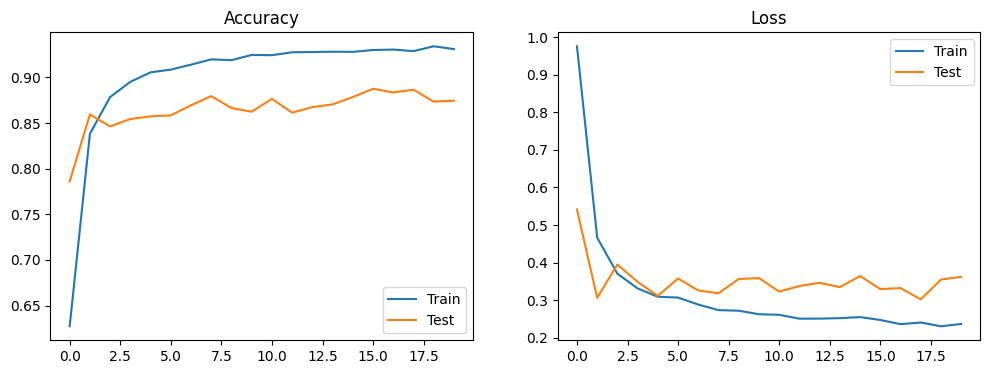

In [18]:
model_v2.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
print(np.shape(Y_train_bal))
# Entraînement
history = model_v2.fit(X_train_bal, Y_train_f, epochs=20, batch_size=32,
                    validation_data=(X_val, Y_val), verbose=1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history.history['accuracy'], label='Train')
ax1.plot(history.history['val_accuracy'], label='Test')
ax1.set_title('Accuracy')
ax1.legend()
ax2.plot(history.history['loss'], label='Train')
ax2.plot(history.history['val_loss'], label='Test')
ax2.set_title('Loss')
ax2.legend()
plt.show()



### Évaluation

{0: 'TWF', 1: 'HDF', 2: 'PWF', 3: 'OSF', 4: 'RNF'} 

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
              precision    recall  f1-score   support

         HDF       0.33      1.00      0.50        14
    No error       1.00      0.87      0.93       965
         OSF       0.32      1.00      0.48         6
         PWF       0.54      1.00      0.70         7
         TWF       0.02      0.67      0.05         3

    accuracy                           0.87       995
   macro avg       0.44      0.91      0.53       995
weighted avg       0.98      0.87      0.92       995



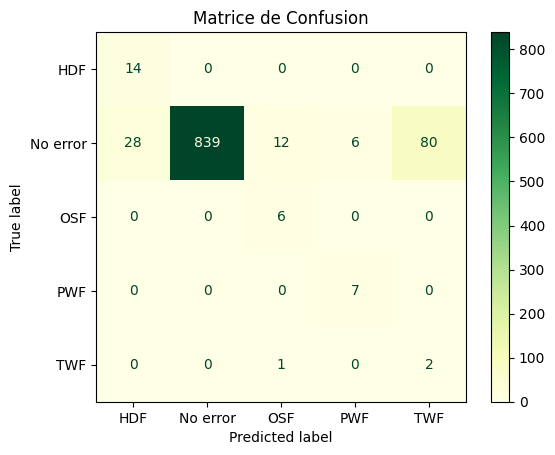

In [19]:
class_mapping = {i: label for i, label in enumerate(Y_df.columns)}
print(class_mapping, "\n")

output_features = ['HDF', 'No error', 'OSF', 'PWF', 'TWF' ]

Y_pred = model_v2.predict(X_test)

Y_pred_idx =np.argmax(Y_pred, axis=1)
Y_test_idx =np.argmax(Y_test, axis=1)

print(classification_report(Y_test_idx, Y_pred_idx, target_names=output_features))


cm = confusion_matrix(Y_test_idx, Y_pred_idx, labels=np.arange(len(output_features)))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=output_features)
disp.plot(cmap=plt.cm.YlGn)
plt.title("Matrice de Confusion")
plt.show()



#### Résultats et comparaison avec la référence

L'analyse de la matrice de confusion donne les résultats suivants :

| Classe | Accuracy | Lecture |
|---|---|---|
| `No Error` | 1,00 | parfaitement reconnue |
| `PWF` | 0,64 | performance correcte |
| `OSF` | 0,38 | performance moyenne |
| `HDF` | 0,33 | performance moyenne |
| `TWF` | 0,02 | très faible |

**Comparaison avec la référence** : le progrès est net et qualitatif. Le rappel sur les classes de défaillance n'est plus nul — le modèle a effectivement appris des patterns de panne, ce que la version non rééquilibrée était structurellement incapable de faire.

**Disparités résiduelles** : elles s'expliquent par la nature des données d'entraînement. Le modèle a majoritairement appris sur des exemples synthétiques générés par interpolation, qui ne reproduisent pas nécessairement les patterns physiques réels des pannes. Le cas de `TWF` est le plus parlant : c'est la classe qui comptait le moins d'exemples réels (46), donc celle dont les exemples synthétiques sont les moins représentatifs.

Cette limite oriente directement les pistes d'amélioration : sur-échantillonnage plus fin (ADASYN), augmentation ciblée sur `TWF`, ou seuillage adaptatif par classe plutôt qu'un simple `argmax`.

## 5. Export pour la cible embarquée

---

Le modèle retenu est sauvegardé au format Keras (`.h5`) puis converti en **TensorFlow Lite**, format d'entrée du générateur de code C X-CUBE-AI.

Empreinte du modèle exporté : **3 077 paramètres**, 12,3 KB de poids en flash, 384 octets de RAM pour les activations et 3 264 MACC par inférence — soit moins de 2 % de la flash et moins de 1 % de la RAM disponibles sur la STM32L4R9.

In [20]:
model_v2.save("DNN_model_failure_prediction.h5")

# Convertir le modèle en TFLite
converter = tf.lite.TFLiteConverter.from_keras_model(model_v2)
tflite_model = converter.convert()

# Sauvegarder le fichier .tflite
with open('DNN_model_failure_prediction.tflite', 'wb') as f:
    f.write(tflite_model)

print("Modèle sauvegardé !")

INFO:tensorflow:Assets written to: C:\Users\rivie\AppData\Local\Temp\tmper_poaaf\assets


INFO:tensorflow:Assets written to: C:\Users\rivie\AppData\Local\Temp\tmper_poaaf\assets


Saved artifact at 'C:\Users\rivie\AppData\Local\Temp\tmper_poaaf'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 5), dtype=tf.float32, name='keras_tensor_8')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  1861106514256: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1861106515216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1861106514832: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1861106514640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1861106514064: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1861106515024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1861106515408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1861078677456: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1861083669584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1861083664592: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1861078674000

### Sauvegarde du jeu de test

Le jeu de test normalisé avec le scaler final est sauvegardé au format `.npy`. Il servira de référence commune aux deux validations : sur desktop via X-CUBE-AI, et sur cible via le script `communication_STM32_NN.py`.

In [ ]:
np.save('X_test_failure_prediction_v2.npy', X_test.astype(np.float32))
np.save('Y_test_failure_prediction_v2.npy', Y_test.astype(np.float32))

### Vérification des tenseurs exportés

Contrôle des dimensions et du contenu avant transfert vers la carte. Chaque échantillon d'entrée fait 5 floats, soit **20 octets** — ce qui correspond exactement à la taille du buffer d'entrée alloué par X-CUBE-AI et à la trame envoyée par UART.

In [23]:
X_test_v2 = np.load("./X_test_failure_prediction_v2.npy")
Y_test_v2 = np.load("./Y_test_failure_prediction_v2.npy")

print("--- ANALYSE DE X_TEST ---")
print(f"Format de X_test : {X_test_v2.shape}")
print(f"Première ligne de X_test :\n{X_test_v2[0]}")
print(f"Valeur max dans X_test : {np.max(X_test_v2):.2f}")

print("\n--- ANALYSE DE Y_TEST ---")
print(f"Format de Y_test : {Y_test_v2.shape}")
print(f"Première ligne de Y_test :\n{Y_test_v2[0]}")

--- ANALYSE DE X_TEST ---
Format de X_test : (995, 5)
Première ligne de X_test :
[ 0.48775354  0.31330565  0.08126678 -0.7028465  -0.32227507]
Valeur max dans X_test : 2.91

--- ANALYSE DE Y_TEST ---
Format de Y_test : (995, 5)
Première ligne de Y_test :
[0. 1. 0. 0. 0.]


---

## Suite du projet

Le modèle `.tflite` produit ici est importé dans **X-CUBE-AI** pour générer le code C embarqué, compilé et flashé sur la STM32L4R9I-DISCO. La validation sur cible compare les prédictions de la carte à celles obtenues sur desktop, sur les 995 échantillons de test transmis par UART à 115 200 bauds.

Le protocole de communication, les mesures d'empreinte et de latence, ainsi que les résultats de validation on-target sont détaillés dans le [README du projet](../README.md).